In [ ]:
# Consumer Insights from Online Reviews
# Sentiment and Textual Analysis
#
# Research Project by Ishant Yadav

In [ ]:
import pandas as pd

df = pd.read_csv(
    "1429_1.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 34660
Columns: 21


In [ ]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [ ]:
df.columns.tolist()

['id',
 'name',
 'asins',
 'brand',
 'categories',
 'keys',
 'manufacturer',
 'reviews.date',
 'reviews.dateAdded',
 'reviews.dateSeen',
 'reviews.didPurchase',
 'reviews.doRecommend',
 'reviews.id',
 'reviews.numHelpful',
 'reviews.rating',
 'reviews.sourceURLs',
 'reviews.text',
 'reviews.title',
 'reviews.userCity',
 'reviews.userProvince',
 'reviews.username']

In [ ]:
important_columns = [
    "name",
    "brand",
    "reviews.date",
    "reviews.didPurchase",
    "reviews.doRecommend",
    "reviews.numHelpful",
    "reviews.rating",
    "reviews.text",
    "reviews.title"
]

df[important_columns].isnull().sum()

,0
name,6760
brand,0
reviews.date,39
reviews.didPurchase,34659
reviews.doRecommend,594
reviews.numHelpful,529
reviews.rating,33
reviews.text,1
reviews.title,6


In [ ]:
df["reviews.rating"].value_counts().sort_index()

,count
reviews.rating,
1.0,410
2.0,402
3.0,1499
4.0,8541
5.0,23775


In [ ]:
pd.set_option("display.max_colwidth", 300)

df[["reviews.rating", "reviews.title", "reviews.text"]].head(10)

,reviews.rating,reviews.title,reviews.text
0,5.0,Kindle,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
1,5.0,very fast,great for beginner or experienced person. Bought as a gift and she loves it
2,5.0,Beginner tablet for our 9 year old son.,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already..."
3,4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love being able to easily access all of the Prime content as well as movies you can download and watch laterThis has a 1280/800 screen which has some reall...
4,5.0,Fantastic Tablet for kids,"I bought this for my grand daughter when she comes over to visit. I set it up with her as the user, entered her age and name and now Amazon makes sure that she only accesses sites and content that are appropriate to her age. Simple to do and she loves the capabilities. I also bought and installe..."
5,5.0,Just what we expected,This amazon fire 8 inch tablet is the perfect size. I purchased it for my husband so that he has a bigger screen than just his phone. He had gotten me one a few years ago so I knew it would be a good purchase.
6,4.0,great e-reader tablet,"Great for e-reading on the go, nice and light weight, and for the price point given, definitely worth the purchase."
7,5.0,Great for gifts,"I gave this as a Christmas gift to my inlaws, husband and uncle. They loved it and how easy they are to use with fantastic features!"
8,5.0,Great for reading,"Great as a device to read books. I like that it links with my borrowed library e-books. Switched from another popular tablet brand and I am happy with the choice I made. It took some time to get books from my previous non-Kindle reader, but finally figured out a way!"
9,5.0,Great and lightweight reader,I love ordering books and reading them with the reader.


In [ ]:
df["review_word_count"] = df["reviews.text"].fillna("").str.split().str.len()

df["review_word_count"].describe()

,review_word_count
count,34660.000000
mean,30.403289
std,34.641440
min,0.000000
25%,13.000000
50%,21.000000
75%,35.000000
max,1858.000000


In [ ]:
empty_reviews = df["reviews.text"].fillna("").str.strip().eq("").sum()

print("Empty reviews:", empty_reviews)

Empty reviews: 1


In [ ]:
df = df[df["reviews.text"].fillna("").str.strip() != ""].copy()

print("Rows after removing empty reviews:", len(df))

Rows after removing empty reviews: 34659


In [ ]:
duplicate_reviews = df["reviews.text"].duplicated().sum()

print("Duplicate review texts:", duplicate_reviews)

Duplicate review texts: 0


In [ ]:
df = df.dropna(subset=["reviews.rating"]).copy()

print("Rows after removing missing ratings:", len(df))

Rows after removing missing ratings: 34626


In [ ]:
print("Recommendation values:")
print(df["reviews.doRecommend"].value_counts(dropna=False))

print("\nHelpful votes:")
print(df["reviews.numHelpful"].describe())

Recommendation values:
reviews.doRecommend
True     32682
False     1384
NaN        560
Name: count, dtype: int64

Helpful votes:
count    34131.000000
mean         0.630248
std         13.215775
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        814.000000
Name: reviews.numHelpful, dtype: float64


In [ ]:
print("Unique products:", df["name"].nunique())
print("Unique brands:", df["brand"].nunique())

Unique products: 48
Unique brands: 5


In [ ]:
df["brand"].value_counts()

,count
brand,
Amazon,28668
Amazon Fire Tv,5056
Amazon Echo,636
Amazon Fire,256
Amazon Digital Services Inc.,10


In [ ]:
df["name"].value_counts().head(15)

,count
name,
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",10962
"Echo (White),,,\r\nEcho (White),,,",3309
"Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,",3176
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",2814
"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",1685
"Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,",1033
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,",580
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",368


In [ ]:
df["product_name_clean"] = (
    df["name"]
    .fillna("Unknown")
    .str.replace(r"\\r\\n", " ", regex=True)
    .str.replace(r",+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[["name", "product_name_clean"]].head(10)

,name,product_name_clean
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
6,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
7,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
8,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta
9,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta


In [ ]:
print("Unique products before cleaning:", df["name"].nunique())
print("Unique products after cleaning:", df["product_name_clean"].nunique())

Unique products before cleaning: 48
Unique products after cleaning: 49


In [ ]:
product_counts = df["product_name_clean"].value_counts()

print(product_counts[product_counts.index.str.contains(
    "Echo|Fire Tv|Kindle", case=False, na=False
)].head(20))

product_name_clean
Echo (White) Echo (White)                                                                                                                                                                                  3309
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black                                                                                                     3176
Amazon Fire Tv Amazon Fire Tv                                                                                                                                                                              2527
Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue                                                                                                                                     1033
Kindle Voyage E-reader 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light PagePress Sensors Wi-Fi - Includes Special Offers            

In [ ]:
df["product_name_clean"].value_counts().head(15)

,count
product_name_clean,
Fire Tablet 7 Display Wi-Fi 8 GB - Includes Special Offers Magenta,10962
Unknown,6759
Echo (White) Echo (White),3309
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,3176
All-New Fire HD 8 Tablet 8 HD Display Wi-Fi 16 GB - Includes Special Offers Magenta,2814
Amazon Fire Tv Amazon Fire Tv,2527
Fire Kids Edition Tablet 7 Display Wi-Fi 16 GB Green Kid-Proof Case,1685
Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,1033
Kindle Voyage E-reader 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light PagePress Sensors Wi-Fi - Includes Special Offers,580


In [ ]:
print("Final rows:", len(df))
print("Columns:", len(df.columns))
print("\nRatings:")
print(df["reviews.rating"].value_counts().sort_index())

Final rows: 34626
Columns: 23

Ratings:
reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23774
Name: count, dtype: int64


In [ ]:
pd.set_option("display.max_colwidth", 300)

df[["reviews.rating", "reviews.title", "reviews.text"]].head(10)

,reviews.rating,reviews.title,reviews.text
0,5.0,Kindle,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
1,5.0,very fast,great for beginner or experienced person. Bought as a gift and she loves it
2,5.0,Beginner tablet for our 9 year old son.,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already..."
3,4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love being able to easily access all of the Prime content as well as movies you can download and watch laterThis has a 1280/800 screen which has some reall...
4,5.0,Fantastic Tablet for kids,"I bought this for my grand daughter when she comes over to visit. I set it up with her as the user, entered her age and name and now Amazon makes sure that she only accesses sites and content that are appropriate to her age. Simple to do and she loves the capabilities. I also bought and installe..."
5,5.0,Just what we expected,This amazon fire 8 inch tablet is the perfect size. I purchased it for my husband so that he has a bigger screen than just his phone. He had gotten me one a few years ago so I knew it would be a good purchase.
6,4.0,great e-reader tablet,"Great for e-reading on the go, nice and light weight, and for the price point given, definitely worth the purchase."
7,5.0,Great for gifts,"I gave this as a Christmas gift to my inlaws, husband and uncle. They loved it and how easy they are to use with fantastic features!"
8,5.0,Great for reading,"Great as a device to read books. I like that it links with my borrowed library e-books. Switched from another popular tablet brand and I am happy with the choice I made. It took some time to get books from my previous non-Kindle reader, but finally figured out a way!"
9,5.0,Great and lightweight reader,I love ordering books and reading them with the reader.


In [ ]:
import re

df["review_text_clean"] = (
    df["reviews.text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[["reviews.text", "review_text_clean"]].head(10)

,reviews.text,review_text_clean
0,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.,this product so far has not disappointed. my children love to use it and i like the ability to monitor control what content they see with ease.
1,great for beginner or experienced person. Bought as a gift and she loves it,great for beginner or experienced person. bought as a gift and she loves it
2,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...","inexpensive tablet for him to use and learn on, step up from the nabi. he was thrilled with it, learn how to skype on it already..."
3,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love being able to easily access all of the Prime content as well as movies you can download and watch laterThis has a 1280/800 screen which has some reall...,i've had my fire hd 8 two weeks now and i love it. this tablet is a great value.we are prime members and that is where this tablet shines. i love being able to easily access all of the prime content as well as movies you can download and watch laterthis has a 1280/800 screen which has some reall...
4,"I bought this for my grand daughter when she comes over to visit. I set it up with her as the user, entered her age and name and now Amazon makes sure that she only accesses sites and content that are appropriate to her age. Simple to do and she loves the capabilities. I also bought and installe...","i bought this for my grand daughter when she comes over to visit. i set it up with her as the user, entered her age and name and now amazon makes sure that she only accesses sites and content that are appropriate to her age. simple to do and she loves the capabilities. i also bought and installe..."
5,This amazon fire 8 inch tablet is the perfect size. I purchased it for my husband so that he has a bigger screen than just his phone. He had gotten me one a few years ago so I knew it would be a good purchase.,this amazon fire 8 inch tablet is the perfect size. i purchased it for my husband so that he has a bigger screen than just his phone. he had gotten me one a few years ago so i knew it would be a good purchase.
6,"Great for e-reading on the go, nice and light weight, and for the price point given, definitely worth the purchase.","great for e-reading on the go, nice and light weight, and for the price point given, definitely worth the purchase."
7,"I gave this as a Christmas gift to my inlaws, husband and uncle. They loved it and how easy they are to use with fantastic features!","i gave this as a christmas gift to my inlaws, husband and uncle. they loved it and how easy they are to use with fantastic features!"
8,"Great as a device to read books. I like that it links with my borrowed library e-books. Switched from another popular tablet brand and I am happy with the choice I made. It took some time to get books from my previous non-Kindle reader, but finally figured out a way!","great as a device to read books. i like that it links with my borrowed library e-books. switched from another popular tablet brand and i am happy with the choice i made. it took some time to get books from my previous non-kindle reader, but finally figured out a way!"
9,I love ordering books and reading them with the reader.,i love ordering books and reading them with the reader.


In [ ]:
!pip -q install textblob

In [ ]:
from textblob import TextBlob

test_review = df["review_text_clean"].iloc[0]

sentiment = TextBlob(test_review).sentiment

print("Review:")
print(test_review)

print("\nSentiment:")
print(sentiment)

Review:
this product so far has not disappointed. my children love to use it and i like the ability to monitor control what content they see with ease.

Sentiment:
Sentiment(polarity=0.325, subjectivity=0.7833333333333333)


In [ ]:
from textblob import TextBlob

df["sentiment_polarity"] = df["review_text_clean"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df["sentiment_subjectivity"] = df["review_text_clean"].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

print("Sentiment analysis completed!")
print(df[[
    "reviews.rating",
    "review_text_clean",
    "sentiment_polarity",
    "sentiment_subjectivity"
]].head(10))

Sentiment analysis completed!
   reviews.rating  \
0             5.0   
1             5.0   
2             5.0   
3             4.0   
4             5.0   
5             5.0   
6             4.0   
7             5.0   
8             5.0   
9             5.0   

                                                                                                                                                                                                                                                                                             review_text_clean  \
0                                                                                                                                                              this product so far has not disappointed. my children love to use it and i like the ability to monitor control what content they see with ease.   
1                                                                                                                             

In [ ]:
rating_sentiment = (
    df.groupby("reviews.rating")["sentiment_polarity"]
    .agg(["mean", "median", "count"])
    .round(3)
)

print(rating_sentiment)

                 mean  median  count
reviews.rating                      
1.0             0.062   0.012    410
2.0             0.109   0.100    402
3.0             0.217   0.200   1499
4.0             0.347   0.333   8541
5.0             0.409   0.400  23774


In [ ]:
def sentiment_category(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_category"] = df["sentiment_polarity"].apply(sentiment_category)

print(df["sentiment_category"].value_counts())

sentiment_category
Positive    31131
Neutral      2000
Negative     1495
Name: count, dtype: int64


In [ ]:
sentiment_rating_table = pd.crosstab(
    df["reviews.rating"],
    df["sentiment_category"],
    normalize="index"
).round(3) * 100

print(sentiment_rating_table)

sentiment_category  Negative  Neutral  Positive
reviews.rating                                 
1.0                     35.9     12.2      52.0
2.0                     25.1      9.0      65.9
3.0                     12.9      6.6      80.5
4.0                      5.0      5.6      89.4
5.0                      2.6      5.6      91.7


In [ ]:
negative_reviews = df[
    df["sentiment_category"] == "Negative"
][[
    "reviews.rating",
    "reviews.title",
    "reviews.text",
    "sentiment_polarity"
]].sample(10, random_state=42)

print(negative_reviews.to_string(index=False))

 reviews.rating                             reviews.title                                                                                                                                              reviews.text  sentiment_polarity
            5.0 Great device for childcare report progran                                                                                            It was not too expensive and it is very useful for our Daycare           -0.055000
            3.0                       Works but not great                                                                          Works but has a tendency to freeze or get slow. Probably wouldn't purchase again           -0.300000
            5.0                         Have a few issues                             Have a few issues. Not sure if its my set up in my home automation. Maybe it's just me. But overall, fantastic job by Amazon.           -0.012500
            4.0             Kindle for reading in the sun               

In [ ]:
correlation = df["reviews.rating"].corr(df["sentiment_polarity"])

print("Correlation between Rating and Sentiment Polarity:", round(correlation, 3))

Correlation between Rating and Sentiment Polarity: 0.236


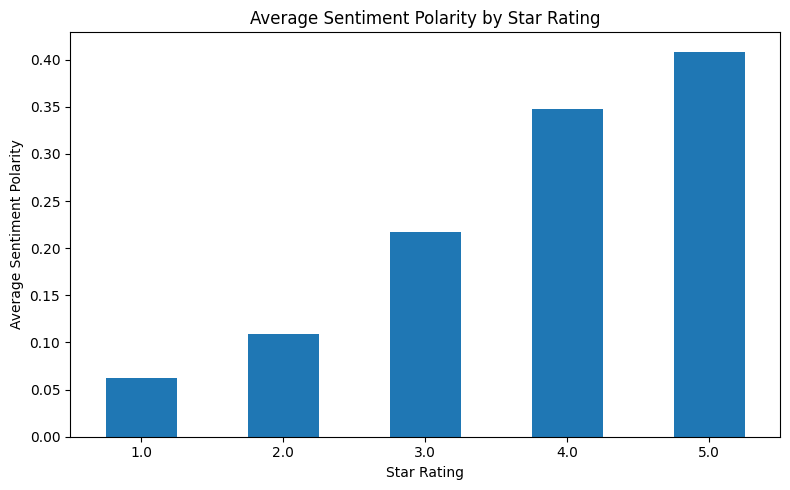

In [ ]:
import matplotlib.pyplot as plt

rating_sentiment_plot = (
    df.groupby("reviews.rating")["sentiment_polarity"]
    .mean()
)

plt.figure(figsize=(8, 5))
rating_sentiment_plot.plot(kind="bar")

plt.title("Average Sentiment Polarity by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Sentiment Polarity")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [ ]:
from collections import Counter
import re

# Combine all review text
all_text = " ".join(df["review_text_clean"].dropna())

# Extract words
words = re.findall(r"\b[a-zA-Z]{3,}\b", all_text)

# Count words
word_counts = Counter(words)

print("Top 30 most common words:")
print(word_counts.most_common(30))

Top 30 most common words:
[('the', 43955), ('and', 33768), ('for', 26324), ('this', 17663), ('great', 11858), ('with', 9470), ('tablet', 9084), ('you', 8518), ('have', 8128), ('that', 7818), ('use', 7682), ('but', 6815), ('love', 6632), ('can', 6545), ('was', 6478), ('easy', 6209), ('amazon', 5874), ('very', 5750), ('not', 5533), ('kindle', 5311), ('good', 5082), ('bought', 5059), ('one', 4994), ('fire', 4826), ('she', 4237), ('price', 4197), ('all', 4165), ('has', 3998), ('like', 3819), ('are', 3735)]


In [ ]:
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords
from collections import Counter
import re

stop_words = set(stopwords.words("english"))

words = re.findall(r"\b[a-zA-Z]{3,}\b", all_text)

meaningful_words = [
    word for word in words
    if word not in stop_words
]

word_counts_clean = Counter(meaningful_words)

print("Top 30 meaningful words:")
print(word_counts_clean.most_common(30))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top 30 meaningful words:
[('great', 11858), ('tablet', 9084), ('use', 7682), ('love', 6632), ('easy', 6209), ('amazon', 5874), ('kindle', 5311), ('good', 5082), ('bought', 5059), ('one', 4994), ('fire', 4826), ('price', 4197), ('like', 3819), ('product', 3583), ('would', 3218), ('works', 3108), ('get', 2990), ('echo', 2945), ('much', 2784), ('music', 2782), ('read', 2756), ('alexa', 2724), ('kids', 2697), ('loves', 2633), ('apps', 2612), ('well', 2587), ('books', 2534), ('reading', 2506), ('device', 2444), ('best', 2408)]


In [ ]:
negative_text = " ".join(
    df.loc[df["sentiment_category"] == "Negative", "review_text_clean"]
    .dropna()
)

negative_words = re.findall(r"\b[a-zA-Z]{3,}\b", negative_text)

negative_meaningful_words = [
    word for word in negative_words
    if word not in stop_words
]

negative_word_counts = Counter(negative_meaningful_words)

print("Top 30 words in negative reviews:")
print(negative_word_counts.most_common(30))

Top 30 words in negative reviews:
[('tablet', 335), ('bought', 260), ('amazon', 250), ('one', 233), ('use', 231), ('like', 195), ('fire', 194), ('get', 190), ('kindle', 175), ('would', 168), ('little', 163), ('loves', 141), ('time', 129), ('apps', 123), ('slow', 118), ('price', 117), ('got', 116), ('purchased', 113), ('well', 113), ('screen', 112), ('works', 107), ('read', 101), ('product', 97), ('work', 96), ('device', 94), ('play', 94), ('alexa', 88), ('echo', 88), ('small', 85), ('books', 83)]


In [ ]:
positive_text = " ".join(
    df.loc[df["sentiment_category"] == "Positive", "review_text_clean"]
    .dropna()
)

positive_words = re.findall(r"\b[a-zA-Z]{3,}\b", positive_text)

positive_meaningful_words = [
    word for word in positive_words
    if word not in stop_words
]

positive_word_counts = Counter(positive_meaningful_words)

print("Top 30 words in positive reviews:")
print(positive_word_counts.most_common(30))

Top 30 words in positive reviews:
[('great', 11792), ('tablet', 8432), ('use', 7247), ('love', 6589), ('easy', 6162), ('amazon', 5444), ('good', 4995), ('kindle', 4965), ('one', 4553), ('fire', 4453), ('bought', 4442), ('price', 3996), ('like', 3407), ('product', 3384), ('would', 2903), ('works', 2874), ('echo', 2779), ('much', 2702), ('get', 2686), ('music', 2626), ('kids', 2562), ('read', 2552), ('alexa', 2551), ('apps', 2435), ('best', 2392), ('books', 2366), ('well', 2360), ('reading', 2347), ('really', 2316), ('device', 2283)]


In [ ]:
negative_total = len(negative_meaningful_words)
positive_total = len(positive_meaningful_words)

comparison = []

all_words = set(negative_word_counts) | set(positive_word_counts)

for word in all_words:
    neg_count = negative_word_counts[word]
    pos_count = positive_word_counts[word]

    neg_rate = neg_count / negative_total
    pos_rate = pos_count / positive_total

    if pos_rate > 0:
        ratio = neg_rate / pos_rate
    else:
        ratio = 0

    comparison.append((word, neg_count, pos_count, ratio))

word_comparison = pd.DataFrame(
    comparison,
    columns=["word", "negative_count", "positive_count", "negative_positive_ratio"]
)

# Require at least 10 occurrences in negative reviews
word_comparison = word_comparison[
    word_comparison["negative_count"] >= 10
]

print(
    word_comparison
    .sort_values("negative_positive_ratio", ascending=False)
    .head(30)
    .to_string(index=False)
)

        word  negative_count  positive_count  negative_positive_ratio
    horrible              12               7                37.480104
       sucks              10              13                16.817995
 complicated              18              27                14.575596
    terrible              16              25                13.992572
    annoying              49              77                13.913069
  frustrated              12              19                13.808459
   confusing              16              26                13.454396
        hate              16              27                12.956085
       waste              17              30                12.389257
      unable              12              24                10.931697
   difficult              47              97                10.593603
disappointed              73             152                10.500183
 advertising              12              29                 9.046922
        poor        

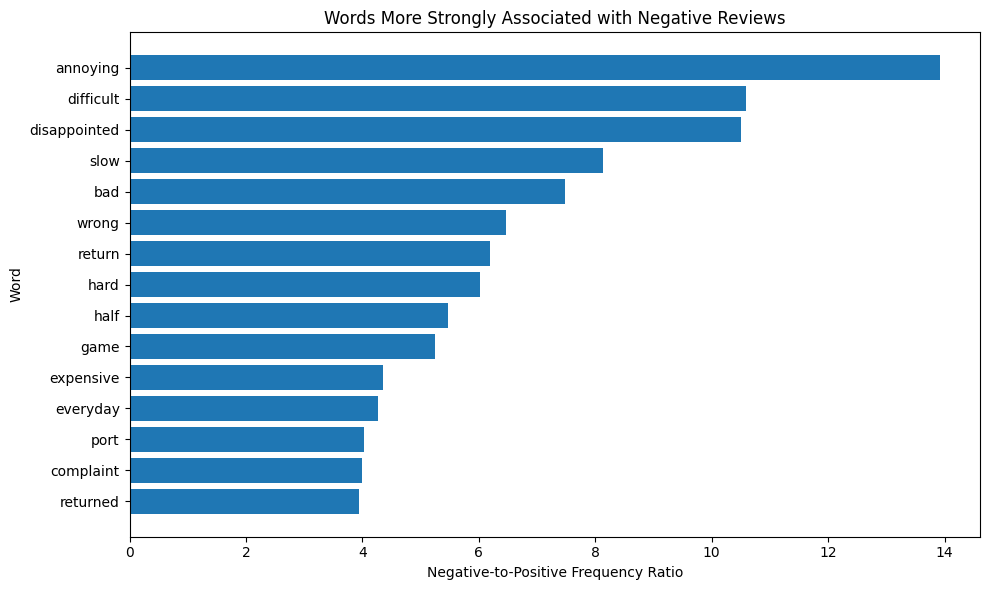

In [ ]:
top_negative_words = (
    word_comparison[
        word_comparison["negative_count"] >= 20
    ]
    .sort_values("negative_positive_ratio", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative_words["word"][::-1],
    top_negative_words["negative_positive_ratio"][::-1]
)

plt.title("Words More Strongly Associated with Negative Reviews")
plt.xlabel("Negative-to-Positive Frequency Ratio")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [ ]:
comparison_positive = []

all_words = set(positive_word_counts) | set(negative_word_counts)

for word in all_words:
    pos_count = positive_word_counts[word]
    neg_count = negative_word_counts[word]

    pos_rate = pos_count / positive_total
    neg_rate = neg_count / negative_total

    if neg_rate > 0:
        ratio = pos_rate / neg_rate
    else:
        ratio = 0

    comparison_positive.append(
        (word, pos_count, neg_count, ratio)
    )

positive_word_comparison = pd.DataFrame(
    comparison_positive,
    columns=[
        "word",
        "positive_count",
        "negative_count",
        "positive_negative_ratio"
    ]
)

# Require at least 20 occurrences in positive reviews
positive_word_comparison = positive_word_comparison[
    positive_word_comparison["positive_count"] >= 20
]

print(
    positive_word_comparison
    .sort_values("positive_negative_ratio", ascending=False)
    .head(30)
    .to_string(index=False)
)

     word  positive_count  negative_count  positive_negative_ratio
  awesome            1005               1                45.967245
excellent             932               1                42.628331
  amazing             822               1                37.597090
  perfect            1620               4                18.524114
 addition             278               1                12.715318
    great           11792              45                11.985534
  helpful             262               1                11.983501
    sound            1141               5                10.437538
    handy             210               1                 9.605096
 favorite             416               2                 9.513619
     love            6589              32                 9.417854
    loved             612               3                 9.330665
     best            2392              13                 8.415894
     nice            1596              10                 7.29

In [ ]:
performance_words = [
    "slow", "freeze", "freezes", "lag", "laggy",
    "crash", "crashes", "broken", "restart",
    "reset", "glitch", "glitches"
]

performance_counts = {}

negative_reviews = df[
    df["sentiment_category"] == "Negative"
]["review_text_clean"].dropna()

for word in performance_words:
    performance_counts[word] = negative_reviews.str.contains(
        rf"\b{word}\b",
        regex=True,
        case=False
    ).sum()

performance_counts = dict(
    sorted(
        performance_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

print("Performance-related terms in negative reviews:")
print(performance_counts)

Performance-related terms in negative reviews:
{'slow': np.int64(102), 'broken': np.int64(18), 'reset': np.int64(10), 'lag': np.int64(8), 'freeze': np.int64(7), 'freezes': np.int64(6), 'restart': np.int64(4), 'laggy': np.int64(2), 'glitch': np.int64(2), 'crash': np.int64(1), 'crashes': np.int64(0), 'glitches': np.int64(0)}


In [ ]:
usability_words = [
    "difficult", "hard", "complicated", "confusing",
    "easy", "simple", "intuitive", "setup",
    "install", "installation", "understand"
]

usability_counts = {}

for word in usability_words:
    usability_counts[word] = negative_reviews.str.contains(
        rf"\b{word}\b",
        regex=True,
        case=False
    ).sum()

usability_counts = dict(
    sorted(
        usability_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

print("Usability-related terms in negative reviews:")
print(usability_counts)

Usability-related terms in negative reviews:
{'hard': np.int64(76), 'difficult': np.int64(46), 'easy': np.int64(41), 'simple': np.int64(25), 'complicated': np.int64(18), 'understand': np.int64(17), 'confusing': np.int64(16), 'install': np.int64(11), 'intuitive': np.int64(6), 'setup': np.int64(5), 'installation': np.int64(0)}


In [ ]:
value_words = [
    "price", "expensive", "cheap",
    "cost", "costly", "value",
    "worth", "overpriced", "affordable"
]

value_counts = {}

for word in value_words:
    value_counts[word] = negative_reviews.str.contains(
        rf"\b{word}\b",
        regex=True,
        case=False
    ).sum()

value_counts = dict(
    sorted(
        value_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

print("Price/value-related terms in negative reviews:")
print(value_counts)

Price/value-related terms in negative reviews:
{'price': np.int64(112), 'expensive': np.int64(58), 'worth': np.int64(23), 'cost': np.int64(15), 'cheap': np.int64(11), 'affordable': np.int64(9), 'value': np.int64(6), 'costly': np.int64(0), 'overpriced': np.int64(0)}


In [ ]:
return_words = [
    "return", "returned", "returning",
    "refund", "refunds", "disappointed",
    "frustrated", "frustrating",
    "annoying", "complaint"
]

return_counts = {}

for word in return_words:
    return_counts[word] = negative_reviews.str.contains(
        rf"\b{word}\b",
        regex=True,
        case=False
    ).sum()

return_counts = dict(
    sorted(
        return_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

print("Return/dissatisfaction-related terms in negative reviews:")
print(return_counts)

Return/dissatisfaction-related terms in negative reviews:
{'disappointed': np.int64(72), 'annoying': np.int64(47), 'return': np.int64(27), 'returned': np.int64(27), 'complaint': np.int64(23), 'returning': np.int64(18), 'frustrating': np.int64(14), 'frustrated': np.int64(12), 'refund': np.int64(5), 'refunds': np.int64(0)}


In [ ]:
themes = {
    "Performance": [
        "slow", "broken", "reset", "lag", "laggy",
        "freeze", "freezes", "restart", "glitch",
        "glitches", "crash", "crashes"
    ],

    "Usability": [
        "hard", "difficult", "complicated", "confusing",
        "easy", "simple", "intuitive", "setup",
        "install", "installation", "understand"
    ],

    "Price / Value": [
        "price", "expensive", "cheap", "cost",
        "costly", "value", "worth", "overpriced",
        "affordable"
    ],

    "Dissatisfaction / Returns": [
        "return", "returned", "returning", "refund",
        "refunds", "disappointed", "frustrated",
        "frustrating", "annoying", "complaint"
    ]
}

theme_results = []

total_negative_reviews = len(negative_reviews)

for theme, words in themes.items():

    mask = negative_reviews.str.contains(
        r"\b(" + "|".join(words) + r")\b",
        regex=True,
        case=False
    )

    review_count = mask.sum()
    percentage = (review_count / total_negative_reviews) * 100

    theme_results.append({
        "Theme": theme,
        "Reviews": review_count,
        "Percentage": round(percentage, 2)
    })

theme_summary = pd.DataFrame(theme_results)

print(theme_summary.sort_values(
    "Percentage",
    ascending=False
).to_string(index=False))

                    Theme  Reviews  Percentage
                Usability      229       15.32
Dissatisfaction / Returns      220       14.72
            Price / Value      212       14.18
              Performance      150       10.03


/tmp/ipykernel_1271/1221570732.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = negative_reviews.str.contains(


In [ ]:
performance_mask = df["review_text_clean"].str.contains(
    r"\b(?:slow|broken|reset|lag|laggy|freeze|freezes|restart|glitch|glitches|crash|crashes)\b",
    regex=True,
    case=False,
    na=False
)

performance_rating = (
    df.loc[performance_mask]
    .groupby("reviews.rating")
    .size()
)

print("Performance-theme mentions by star rating:")
print(performance_rating)

Performance-theme mentions by star rating:
reviews.rating
1.0     48
2.0     60
3.0    151
4.0    294
5.0    222
dtype: int64


In [ ]:
performance_by_rating = (
    df.assign(performance_mention=performance_mask)
      .groupby("reviews.rating")["performance_mention"]
      .agg(["sum", "count"])
)

performance_by_rating["percentage"] = (
    performance_by_rating["sum"]
    / performance_by_rating["count"]
    * 100
)

print(
    performance_by_rating.round(2)
)

                sum  count  percentage
reviews.rating                        
1.0              48    410       11.71
2.0              60    402       14.93
3.0             151   1499       10.07
4.0             294   8541        3.44
5.0             222  23774        0.93


In [ ]:
usability_mask = df["review_text_clean"].str.contains(
    r"\b(?:hard|difficult|complicated|confusing|easy|simple|intuitive|setup|install|installation|understand)\b",
    regex=True,
    case=False,
    na=False
)

usability_by_rating = (
    df.assign(usability_mention=usability_mask)
      .groupby("reviews.rating")["usability_mention"]
      .agg(["sum", "count"])
)

usability_by_rating["percentage"] = (
    usability_by_rating["sum"]
    / usability_by_rating["count"]
    * 100
)

print(usability_by_rating.round(2))

                 sum  count  percentage
reviews.rating                         
1.0               52    410       12.68
2.0               65    402       16.17
3.0              228   1499       15.21
4.0             1771   8541       20.74
5.0             4858  23774       20.43


In [ ]:
difficulty_mask = df["review_text_clean"].str.contains(
    r"\b(?:hard|difficult|complicated|confusing|unable)\b",
    regex=True,
    case=False,
    na=False
)

difficulty_by_rating = (
    df.assign(difficulty_mention=difficulty_mask)
      .groupby("reviews.rating")["difficulty_mention"]
      .agg(["sum", "count"])
)

difficulty_by_rating["percentage"] = (
    difficulty_by_rating["sum"]
    / difficulty_by_rating["count"]
    * 100
)

print(difficulty_by_rating.round(2))

                sum  count  percentage
reviews.rating                        
1.0              29    410        7.07
2.0              38    402        9.45
3.0              79   1499        5.27
4.0             244   8541        2.86
5.0             232  23774        0.98


In [ ]:
value_mask = df["review_text_clean"].str.contains(
    r"\b(?:price|expensive|cheap|cost|costly|value|worth|overpriced|affordable)\b",
    regex=True,
    case=False,
    na=False
)

value_by_rating = (
    df.assign(value_mention=value_mask)
      .groupby("reviews.rating")["value_mention"]
      .agg(["sum", "count"])
)

value_by_rating["percentage"] = (
    value_by_rating["sum"]
    / value_by_rating["count"]
    * 100
)

print(value_by_rating.round(2))

                 sum  count  percentage
reviews.rating                         
1.0               58    410       14.15
2.0               65    402       16.17
3.0              322   1499       21.48
4.0             1781   8541       20.85
5.0             3610  23774       15.18


In [ ]:
dissatisfaction_mask = df["review_text_clean"].str.contains(
    r"\b(?:return|returned|returning|refund|refunds|disappointed|frustrated|frustrating|annoying|complaint)\b",
    regex=True,
    case=False,
    na=False
)

dissatisfaction_by_rating = (
    df.assign(dissatisfaction_mention=dissatisfaction_mask)
      .groupby("reviews.rating")["dissatisfaction_mention"]
      .agg(["sum", "count"])
)

dissatisfaction_by_rating["percentage"] = (
    dissatisfaction_by_rating["sum"]
    / dissatisfaction_by_rating["count"]
    * 100
)

print(dissatisfaction_by_rating.round(2))

                sum  count  percentage
reviews.rating                        
1.0             113    410       27.56
2.0              93    402       23.13
3.0             162   1499       10.81
4.0             317   8541        3.71
5.0             258  23774        1.09


In [ ]:
print(df["reviews.numHelpful"].describe())

print("\nReviews with helpful votes:")
print((df["reviews.numHelpful"] > 0).sum())

print("\nReviews with zero helpful votes:")
print((df["reviews.numHelpful"] == 0).sum())

count    34131.000000
mean         0.630248
std         13.215775
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        814.000000
Name: reviews.numHelpful, dtype: float64

Reviews with helpful votes:
3311

Reviews with zero helpful votes:
30820


In [ ]:
df["has_helpful_vote"] = (df["reviews.numHelpful"] > 0).astype(int)

print(df["has_helpful_vote"].value_counts())

has_helpful_vote
0    31315
1     3311
Name: count, dtype: int64


In [ ]:
helpful_by_length = (
    df.groupby("has_helpful_vote")["review_word_count"]
    .agg(["mean", "median", "count"])
    .round(2)
)

print(helpful_by_length)

                   mean  median  count
has_helpful_vote                      
0                 28.29    20.0  31315
1                 48.75    29.0   3311


In [ ]:
helpful_by_rating = (
    df.groupby("reviews.rating")["has_helpful_vote"]
    .agg(["sum", "count"])
)

helpful_by_rating["percentage"] = (
    helpful_by_rating["sum"]
    / helpful_by_rating["count"]
    * 100
)

print(helpful_by_rating.round(2))

                 sum  count  percentage
reviews.rating                         
1.0              146    410       35.61
2.0               85    402       21.14
3.0              162   1499       10.81
4.0              898   8541       10.51
5.0             2020  23774        8.50


In [ ]:
helpful_by_sentiment = (
    df.groupby("has_helpful_vote")["sentiment_polarity"]
    .agg(["mean", "median", "count"])
    .round(3)
)

print(helpful_by_sentiment)

                   mean  median  count
has_helpful_vote                      
0                 0.381   0.380  31315
1                 0.341   0.329   3311


In [ ]:
correlation_length = df["review_word_count"].corr(
    df["has_helpful_vote"]
)

print("Correlation between review length and helpfulness:", round(correlation_length, 3))

Correlation between review length and helpfulness: 0.177


In [ ]:
helpful_length_rating = (
    df.groupby(["has_helpful_vote", "reviews.rating"])["review_word_count"]
    .mean()
    .round(2)
)

print(helpful_length_rating)

has_helpful_vote  reviews.rating
0                 1.0               39.42
                  2.0               41.89
                  3.0               35.99
                  4.0               30.55
                  5.0               26.69
1                 1.0               62.32
                  2.0               66.20
                  3.0               61.16
                  4.0               51.16
                  5.0               44.96
Name: review_word_count, dtype: float64


In [ ]:
print("===== FINAL PROJECT SUMMARY =====")

print("Total reviews:", len(df))
print("Unique products:", df["product_name_clean"].nunique())
print("Unique brands:", df["brand"].nunique())

print("\n--- Sentiment ---")
print(df["sentiment_category"].value_counts())

print("\n--- Ratings ---")
print(df["reviews.rating"].value_counts().sort_index())

print("\n--- Helpful Reviews ---")
print(df["has_helpful_vote"].value_counts())

print("\n--- Key Correlations ---")
print(
    "Rating vs Sentiment:",
    round(df["reviews.rating"].corr(df["sentiment_polarity"]), 3)
)

print(
    "Review Length vs Helpfulness:",
    round(df["review_word_count"].corr(df["has_helpful_vote"]), 3)
)

===== FINAL PROJECT SUMMARY =====
Total reviews: 34626
Unique products: 49
Unique brands: 5

--- Sentiment ---
sentiment_category
Positive    31131
Neutral      2000
Negative     1495
Name: count, dtype: int64

--- Ratings ---
reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23774
Name: count, dtype: int64

--- Helpful Reviews ---
has_helpful_vote
0    31315
1     3311
Name: count, dtype: int64

--- Key Correlations ---
Rating vs Sentiment: 0.236
Review Length vs Helpfulness: 0.177


## Key Findings

1. The dataset contains 34,626 consumer reviews across 49 products and 5 brands.

2. Review sentiment showed a positive relationship with star ratings.
   The correlation between rating and TextBlob sentiment polarity was 0.236.

3. Dissatisfaction and return-related language was much more common in lower-rated reviews:
   - 1-star: 27.56%
   - 2-star: 23.13%
   - 3-star: 10.81%
   - 4-star: 3.71%
   - 5-star: 1.09%

4. Performance-related terms such as "slow", "broken", "freeze" and "lag"
   were more prevalent in lower-rated reviews.

5. Difficulty-related language such as "hard", "difficult", "complicated",
   "confusing" and "unable" was more prevalent in lower-rated reviews.

6. Price/value-related language appeared across different rating levels,
   showing a non-linear pattern rather than a simple positive or negative relationship.

7. Reviews receiving helpful votes were longer on average:
   - No helpful votes: 28.29 words
   - At least one helpful vote: 48.75 words

8. Review length had a positive correlation of 0.177 with having at least one
   helpful vote.

9. Helpful reviews were also less positive in sentiment on average
   (0.341 vs 0.381), suggesting that helpfulness was not simply associated
   with more positive language.

## Limitations

- TextBlob sentiment is an automated sentiment signal, not ground-truth sentiment.
- Keyword-based theme detection does not capture every way consumers express an issue.
- Themes can overlap within the same review.
- The dataset is heavily concentrated in Amazon-branded products, so brand-level
  comparisons should be interpreted cautiously.
- The analysis identifies associations and patterns, not causal relationships.
- Some malformed CSV rows were skipped during loading using `on_bad_lines="skip"`.